# 3. POT и GPD

**Цели:** выбрать высокий порог, оценить GPD и выполнить точечную детекцию.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


(GPDFit(threshold=2.615415576881738, sigma_u=0.5968437647659459, xi=0.6913130064962861, exceedances=array([ 0.40883462,  0.31585017,  1.41148646,  1.02051548,  0.37361066,
         1.11952194,  0.64253772,  0.37679362, 12.26897623, 10.21417855,
        11.24236487,  0.40691101,  0.24153237,  1.41407731,  1.04717189,
         1.14264257,  0.09445999,  0.88028573,  0.91192016,  0.03858805,
         0.06190382,  1.85409304,  0.75502963,  0.13232528,  1.65975763,
         0.87410413,  0.33639078,  0.82226967,  0.53818906,  0.05688463,
         0.46798976,  0.18007581, 11.65196275, 11.21263642, 11.47714702,
         0.27665399,  0.5772948 ,  0.504424  ,  0.51582723,  0.6295929 ,
         0.61749749,  0.31170628,  0.49396908,  0.12730557,  0.92938646,
         0.23247923,  0.01922211, 12.86120439, 14.18623809, 13.39927537,
         2.31254979,  2.17824229,  0.51224619,  0.8557117 ,  0.83633544,
         0.4860447 ,  0.17537272,  0.20676195,  0.52504785,  0.18631432,
         0.45174082,  1.1

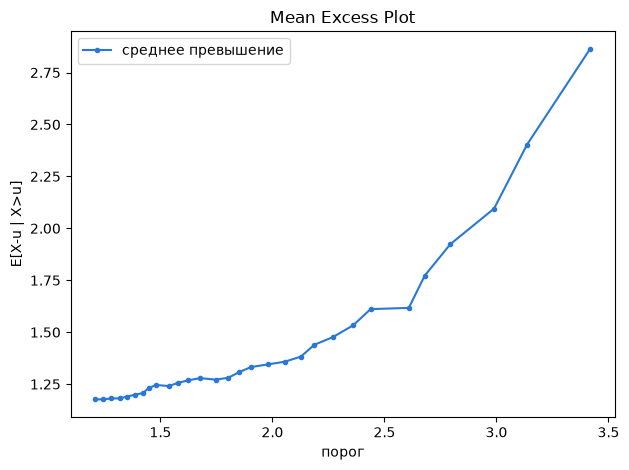

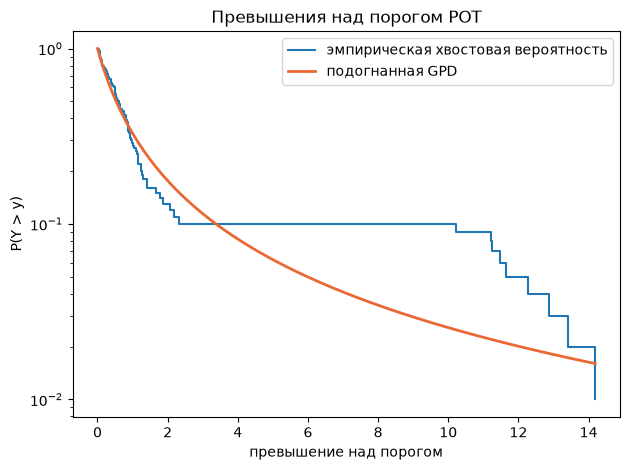

In [2]:
import numpy as np
from evt_demo import EVTAnalyzer, generate_time_series_with_extreme_events
from evt_demo.visualization import plot_gpd_exceedances, plot_mean_excess
series, truth = generate_time_series_with_extreme_events(seed=42)
a=EVTAnalyzer(); fit=a.fit_gpd_peaks_over_threshold(series, threshold_percentile=95)
detected=a.detect_extremes_via_pot(series, fit, tail_probability=.05)
plot_mean_excess(series, np.percentile(series, np.linspace(80,98,30)), "../figures/notebook_03_mean_excess.png")
plot_gpd_exceedances(fit, "../figures/notebook_03_gpd.png")
fit, int(detected.sum())

Mean Excess Plot — диагностика, а не автоматическое доказательство правильного порога. Зависимые превышения в реальной задаче могут требовать кластеризации.

**Самопроверка:** 1) Как порог меняет bias/variance? 2) Почему `loc=0`? 3) Что означает условная tail probability?